# Lab 0: Welcome to the Qiskit Global Summer School 2026 

This is Lab 0, your warm-up notebook to get you ready for the main event. In this lab, you will:

- Upgrade your Python packages
- Complete simple coding exercises with Sampler and Estimator
- Build a special multi-qubit quantum circuit and explore its statevector
- *(Optional)* Build a quantum circuit in C using the Qiskit C API

Excited? There's plenty more ahead!


This lab runs on macOS, Linux, and cloud platforms like [qBraid](https://qbraid.com/) and [Google Colab](https://colab.research.google.com/). If you're on Windows, we recommend using a cloud platform for the best experience, especially for the upcoming labs where some packages work best in Linux-based environments.

Here's a quick summary:

| Your OS | How to run this lab |
|---|---|
| macOS / Linux | Run locally — the notebook handles setup for you. |
| Windows | Chapters 1–2 run locally with Python and venv. For the optional chapter 3, open this notebook on [qBraid](https://qbraid.com/) or [Google Colab](https://colab.research.google.com/). |

<br>


## Installation

Run this cell first to check your Python version.

In [1]:
import sys

# Qiskit 2.x requires Python >= 3.9; 3.10+ is what the summer school targets, so
# anything older is warned about rather than hard-failed (the labs may still work).
recommended = (3, 10)
current = sys.version_info[:2]

if current < recommended:
    print(f"You are using Python {current[0]}.{current[1]}. Python {recommended[0]}.{recommended[1]} or later is recommended.")
else:
    print(f"Python {current[0]}.{current[1]} — looks good!")

Python 3.12 — looks good!


Next, run the cell below to install and upgrade the required packages. If the upgrade process causes dependency conflicts with packages already installed in your local environment, __create a new Python environment__ (Python 3.12 recommended) and continue the challenge there. 

For guidance on setting up a clean environment and installing Qiskit, refer to the IBM Quantum documentation: https://quantum.cloud.ibm.com/docs/guides/install-qiskit

In [ ]:
# Install required packages.
# Uncomment the lines below the first time you run this notebook to install dependencies,
# then re-comment them on subsequent runs.


%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib
%pip install --upgrade qc-grader

Once you have installed and upgraded the libraries, please restart the Python kernel and rerun the notebook starting from the Import Libraries cell below.

In [3]:
import os
import platform
import shutil
import subprocess
import sys

import qc_grader
import qiskit

# NOTE: `qc_grader` was the Qiskit Global Summer School grading client. It called a
# hosted IBM service to score answers. That service is retired, so every
# `grade_lab*_ex*(...)` / `check_progress(...)` cell in this repository will fail if
# re-run. The cells are kept in place so the notebook still reads as the original
# graded lab, and the stored outputs show the scores as they were received in 2026.
from qc_grader.challenges.qgss_2026 import check_progress
from qc_grader.challenges.qgss_2026.lab0 import (
    grade_lab0_ex1,
    grade_lab0_ex2,
    grade_lab0_ex3,
    grade_lab0_ex4,
)


from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
# generate_preset_pass_manager builds the transpilation pipeline (layout -> routing ->
# basis translation -> optimisation) for a given backend.
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere
from qiskit_aer import AerSimulator
# Batch groups several primitive jobs into one backend reservation (see Section 1.8).
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt

print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")

Qiskit version: 2.5.1
Grader version: 2026.7.28


# Chapter 1 — Your first quantum program with Qiskit patterns

## 1.1 IBM Quantum Account

First things first! To participate in the main event, you'll need an active IBM Quantum account.

If you've already saved your account credentials with `QiskitRuntimeService`, you can just run the cell below and your backend list will appear. If you're a new user, or it's been a while since you last set things up, follow these steps to save your account:

1. Go to [quantum.cloud.ibm.com](https://quantum.cloud.ibm.com/) and sign in (or create an account).
2. Copy your API key by clicking `Create +` or `View all` on the dashboard.
3. Copy your instance CRN from the Instances tab.
4. Replace the placeholders in the cell below with your API key and Instance CRN, then run it.

Once that's done, run the grader cell to confirm your credentials are set up correctly.

> **Credential handling in this repository.** The cell below is left fully commented
> out on purpose. `QiskitRuntimeService.save_account(...)` writes your API key to
> `~/.qiskit/qiskit-ibm.json` *outside* the repository, which is exactly where it
> should live — a token pasted into a notebook cell gets committed along with the
> notebook. No real API key, CRN, or account identifier appears anywhere in this
> repository; the strings below are IBM's placeholders.

In [ ]:
# Paste your IBM Cloud credentials here. You only need to do this once per environment.
# After it works, you can comment these lines out so the credentials do not stay in the file.
#
# save_account() persists the token to ~/.qiskit/qiskit-ibm.json (NOT into this
# notebook), so subsequent sessions can just call QiskitRuntimeService() with no
# arguments. `instance` is the CRN of the IBM Cloud service instance that owns your
# QPU allocation; `set_as_default=True` makes it the account picked up automatically.

#token = "<YOUR_API_KEY>"
#instance = "<YOUR_CRN>"  # looks like "crn:v1:bluemix:public:quantum-computing:..."

#QiskitRuntimeService.save_account(
#    token=token,
#    instance=instance,
#    overwrite=True,
#    set_as_default=True,
#)

# # Verify: listing backends is the cheapest call that proves authentication works.
# service = QiskitRuntimeService()
# backends = service.backends()
# print(f"Account OK. {len(backends)} backend(s) available:")
# for b in backends[:5]:
#     print(f"  {b.name} ({b.num_qubits} qubits)")

<div class="alert alert-block alert-success">
  <b>Exercise 1: Verify your IBM Quantum account</b>

  Have you set your API key and CRN and checked the available backends?
  Run the Exercise 1 cell below to make sure the grader works properly.
  You don’t need to enter anything!

  If your account is configured correctly, you will see a success message.
</div>


In [5]:
grade_lab0_ex1()

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-30 16:28:51,672: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Your IBM Quantum account is properly configured!
You have successfully connected to the grading server.
You're all set to continue with the rest of the lab.
You scored 1 on this exercise.


## 1.2 Quantum Computing with Gates

IBM quantum computers are gate-based. We build quantum algorithms by composing quantum gates, much like classical computers use AND, OR, and NOT gates to process bits. A key difference is that quantum gates work on qubits, the quantum counterpart of classical bits. Classical bits are strictly 0 or 1, but qubits can exhibit three quantum mechanical phenomena: superposition (a qubit exists in a linear combination of 0 and 1 until measured), entanglement (two or more qubits share a joint quantum state that cannot be described by the individual qubits independently), and interference (quantum amplitudes can add constructively or destructively, allowing algorithms to suppress wrong answers and reinforce correct ones). These three phenomena are what make quantum computing different from classical computing.

### Superposition and the Hadamard Gate

The [Hadamard gate (H)](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.HGate) takes a qubit in a definite state ($|0\rangle$ or $|1\rangle$) and puts it into an equal superposition of both:

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \qquad H|0\rangle = \frac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr)$$

When you measure this state, you get 0 or 1 with equal probability (50% each). The $\frac{1}{\sqrt{2}}$ coefficients are probability amplitudes, and the measurement probability of each outcome is the square of its amplitude.

Complete the cell below to build your first 1-qubit circuit with a Hadamard gate.

<br>

<div class="alert alert-block alert-info">

To learn more about superposition, entanglement, and interference, see the [Basics of quantum information](https://quantum.cloud.ibm.com/learning/courses/basics-of-quantum-information) course.

</div>


<div class="alert alert-block alert-success">
<b>Exercise 2: Build your first quantum circuit</b>

Below is an empty 1-qubit circuit. Add a <b>Hadamard gate</b> on qubit 0 to put it into superposition. This is what gives you the characteristic 50/50 split when we run the Sampler in Section 1.6.

Hint: try our official [QuickStart](https://quantum.cloud.ibm.com/docs/guides/quick-start).

</div>


**Solution — Exercise 2.** One gate is needed: `qc.h(0)`.

Starting from the default initial state $|0\rangle$, the Hadamard gate maps

$$H|0\rangle = \tfrac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr),$$

an equal-amplitude superposition. Both amplitudes are $+1/\sqrt{2}$, so both
measurement probabilities are $|1/\sqrt{2}|^2 = 1/2$ — the 50/50 split the grader
checks for in Section 1.6.

No measurement is added here. `Statevector` and `EstimatorV2` both need a circuit
*without* measurements (a measurement collapses the state and destroys the
amplitudes they need); `SamplerV2` gets its own measured copy in Section 1.5.

Imports loaded successfully — you're ready to go.


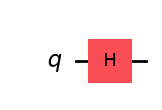

In [4]:
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt
import numpy as np

print("Imports loaded successfully — you're ready to go.")

# QuantumCircuit(1) -> one qubit, zero classical bits, initialised to |0>.
qc = QuantumCircuit(1)

# TODO: Add a Hadamard gate on qubit 0
# H maps |0> -> (|0> + |1>)/sqrt(2): equal amplitudes, hence a 50/50 measurement split.
qc.h(0)

# "mpl" renders with matplotlib; "text" and "latex" are the other drawers.
qc.draw("mpl")

## 1.3 What is a Qiskit pattern?

We now have a quantum circuit that prepares the $H|0\rangle$ superposition state. In the next sections, we will run two experiments on this circuit: one to collect measurement counts, and one to compute the expectation value of the Z observable. Both experiments follow the same four-step workflow called a [Qiskit pattern](https://quantum.cloud.ibm.com/docs/guides/intro-to-patterns).

| Step | What you do | In this lab |
|------|------------|-------------|
| 1. Map | Map the problem to quantum circuits and operators. | We build the H circuit and define the Z observable. |
| 2. Optimize | Optimize the circuit for target hardware. | We use `generate_preset_pass_manager` to do this. |
| 3. Execute | Execute on target hardware using primitives. | We run the circuit with both Sampler and Estimator. |
| 4. Post-process | Post-process results. | We plot the measurement histogram and verify that ⟨Z⟩ ≈ 0. |

For the Execute step, Qiskit provides two primitives:

- [SamplerV2](https://quantum.cloud.ibm.com/docs/guides/primitives) samples the output register from quantum circuit execution. We use it to collect measurement counts and verify that 0 and 1 appear with roughly equal frequency.
- [EstimatorV2](https://quantum.cloud.ibm.com/docs/guides/primitives) computes expectation values of observables with respect to states prepared by quantum circuits. We use it to evaluate $\langle Z \rangle$, where $|0\rangle$ has eigenvalue $+1$ and $|1\rangle$ has eigenvalue $-1$, giving $\langle Z \rangle = 0$ for an equal superposition.

The next sections go through each step.

## 1.4 Step 1 — Map

In the Map step, we define the quantum problem as a circuit and an observable.

The circuit is already built: `qc` prepares the $H|0\rangle$ state. Here we define the observable. We use the Z operator (Pauli-Z), which has eigenvalue $+1$ for $|0\rangle$ and $-1$ for $|1\rangle$:

$$Z = |0\rangle\langle 0| - |1\rangle\langle 1|$$

For the $H|0\rangle$ state, both outcomes are equally likely, so the expectation value is:

$$\langle Z \rangle = \frac{1}{2}(+1) + \frac{1}{2}(-1) = 0$$

This is what we will verify with Estimator in the Execute step.

<div class="alert alert-block alert-success">
<b>Exercise 3: Define the observable</b>

In the Map step, you choose what to measure. We want the Pauli-Z operator on qubit 0; its expectation value tells us how biased the qubit is toward |0⟩ vs |1⟩.

Create a single-qubit Z __observable__ using <code>SparsePauliOp</code> with a coefficient $1.0$.

Hint: you can find nice examples in our [SparsePauliOp documentation](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.quantum_info.SparsePauliOp).

</div>


**Solution — Exercise 3.** `observable = SparsePauliOp("Z", coeffs=[1.0])`.

`SparsePauliOp` stores an operator as a weighted sum of Pauli strings,
$\sum_k c_k P_k$, keeping only the non-zero terms. Here there is a single term with
Pauli string `"Z"` and coefficient $c_0 = 1.0$, i.e. the bare operator

$$Z = |0\rangle\langle 0| - |1\rangle\langle 1|.$$

Two details that matter later:

- **String length = number of qubits.** `"Z"` is a one-qubit operator, matching the
  one-qubit circuit. For the 6-qubit circuits in Chapter 2 you would write something
  like `"ZIIIII"`, with the *leftmost* character acting on the *highest-index* qubit
  (Qiskit's little-endian convention).
- **`coeffs` is a list, not a scalar**, because the general form carries one
  coefficient per Pauli string. It may be complex, but the operator is only Hermitian
  — and therefore a valid observable — when the coefficients are real.

The expected value for $H|0\rangle$: $\langle Z\rangle = \tfrac12(+1) + \tfrac12(-1) = 0$.

In [5]:

# TODO: Define the observable as the single-qubit Z operator
# SparsePauliOp = sum of Pauli strings with coefficients. One string "Z", coefficient
# 1.0, so this is plain Pauli-Z: eigenvalue +1 on |0>, -1 on |1>.
observable = SparsePauliOp("Z", coeffs=[1.0])

print(f"Observable: {observable}")

NameError: name 'SparsePauliOp' is not defined

## 1.5 Step 2 — Transpile

Quantum hardware has constraints. Real quantum hardware has a native gate set and a qubit connectivity that are determined by the underlying physical implementation. The `Transpile` step rewrites your abstract circuit into an equivalent circuit that the target backend can actually execute, using its supported gate set and connectivity.

We use `generate_preset_pass_manager` to handle this. In the cells below, we target an ideal simulator, which accepts nearly any gate, so the transpiled circuit will look close to the original. In the optional Section 1.8, we run on real hardware where the transpiler does more work: decomposing gates into the backend's native gate set and optimizing the circuit layout according to the connectivity constraints.

Transpilation applies to both the circuit and the observable. When the transpiler assigns virtual qubits to physical qubits, the observable must reflect that same mapping. We do this with `apply_layout`. Since our circuit has only one qubit, the layout is trivial here, but the same pattern is required for multi-qubit circuits on real hardware.


In [11]:
backend = AerSimulator()
# optimization_level=1 is the default trade-off: light gate cancellation, no heavy
# resynthesis. Levels run 0 (layout only) to 3 (most aggressive, slowest).
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

# Sampler requires measurements in the circuit
# measure_all() appends a barrier, a fresh classical register named "meas", and one
# measurement per qubit — which is why the result is read back as `data.meas` below.
qc_meas = qc.copy()
qc_meas.measure_all()
isa_qc_meas = pm.run(qc_meas)

# Estimator takes the circuit without measurements and evaluates the observable separately
isa_qc = pm.run(qc)

# Apply the same layout to the observable so qubit indices match the transpiled circuit
# The transpiler may permute virtual -> physical qubits; apply_layout pads and permutes
# the Pauli string identically, so "Z" keeps acting on the qubit it was meant for.
isa_observable = observable.apply_layout(isa_qc.layout)

print("Transpiled circuit and observable ready.")

AttributeError: 'NoneType' object has no attribute 'apply_layout'

## 1.6 Step 3 — Execute

Now we run the transpiled circuit using both primitives. Each answers a different question about the same quantum state.

### Sampler: "What counts do I get?"

The Sampler runs your circuit many times (shots) and counts how often each outcome occurs: how many times do I measure 0, and how many times do I measure 1?

In [ ]:
# mode=backend runs in "job mode": each run() is an independent job on that backend.
sampler = Sampler(mode=backend)
# run() takes a list of PUBs (Primitive Unified Blocs). For Sampler a PUB is just the
# circuit; .result() blocks until the job finishes.
sampler_result = sampler.run([isa_qc_meas], shots=1000).result()
# One result entry per PUB, hence [0]. `.data.meas` is the register measure_all() created.
counts = sampler_result[0].data.meas.get_counts()

print("Sampler counts:", counts)

<div class="alert alert-block alert-success">
<b>Submit & check your Sampler result to complete Exercise 2</b>

The <code>counts</code> you just computed comes from the H circuit you built in Section 1.2. Run the cell below to submit it; the grader checks for the 50/50 split.

</div>


In [ ]:
grade_lab0_ex2(counts)

### Estimator: "What value do I get when I observe my quantum circuit?"

Estimator takes the circuit and the observable and returns the expectation value directly, without you having to collect and average counts manually. The circuit does not need measurement gates — Estimator handles the measurement internally.

For the $H|0\rangle$ state, we expect $\langle Z \rangle = 0$.


In [ ]:
# Run Estimator — circuit WITHOUT measurements + observable
estimator = Estimator(mode=backend)
# An Estimator PUB is the tuple (circuit, observable[, parameter_values]). The
# primitive chooses its own measurement bases and shot budget internally.
estimator_result = estimator.run([(isa_qc, isa_observable)]).result()
# `evs` = expectation values; `stds` (used below) is the matching standard error.
exp_val = estimator_result[0].data.evs

print(f"⟨Z⟩ = {exp_val:.4f}")

<div class="alert alert-block alert-success">
<b>Submit & check your Estimator result to complete Exercise 3</b>

Run the cell below to submit <code>exp_val</code> to the grader. For a perfect H|0⟩ superposition, ⟨Z⟩ should be ≈ 0.

</div>


In [ ]:
grade_lab0_ex3(exp_val)

## 1.7 Step 4 — Post-process

The Post-process step is where we extract meaning from the raw results. Depending on the problem, this can mean visualizing measurement distributions, computing derived quantities from expectation values, feeding results into a classical optimization loop, or applying error mitigation techniques.

In this lab, we keep it simple. We plot the Sampler counts as a histogram to see how often 0 and 1 were measured, and we plot the Estimator result as a bar chart with an error bar showing the statistical uncertainty on $\langle Z \rangle$. On the simulator we expect equal counts and $\langle Z \rangle \approx 0$. On real hardware, both plots will reflect the effect of shot and device noise.

In [ ]:

# Sampler results
print(f"Sampler counts: {counts}")
display(plot_histogram(counts, title="H|0⟩ measurement distribution (1000 shots)"))

# Estimator results
# .evs / .stds are 0-d numpy arrays for a single-observable PUB; .item() unwraps them.
ev = estimator_result[0].data.evs.item()
std = estimator_result[0].data.stds.item()
print(f"\nEstimator ⟨Z⟩ = {ev:.4f} ± {std:.4f}")

fig, ax = plt.subplots(figsize=(4, 5))
# yerr draws the 1-sigma statistical uncertainty: shot noise shrinks as 1/sqrt(shots).
ax.bar(["⟨Z⟩"], [ev], yerr=[std], capsize=10, color="steelblue", width=0.4)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")  # the ideal value
# Z has eigenvalues +/-1, so the expectation value can never leave [-1, 1].
ax.set_ylim(-1.2, 1.2)
ax.set_ylabel("Expectation value")
ax.set_title("Z observable on H|0⟩ (Estimator)")
plt.tight_layout()
plt.show()

## 1.8 (Optional) Run on Real Quantum Hardware

<div class="alert alert-block alert-info">
<b>This section is optional and ungraded.</b> It submits jobs to a real quantum computer and uses your QPU time. You can skip it and continue to Chapter 2.
</div>

So far we used a simulator. Now we run the same circuit on a real IBM quantum processor. The code follows the same Qiskit Patterns workflow. The only change is the backend.

Real quantum hardware operates under physical constraints that simulators do not have. Gates run as microwave pulses on physical qubits, and each operation has a finite fidelity. As a result, the counts will be close to 50/50 but not exact, and $\langle Z \rangle$ will be close to 0 with a measurable uncertainty. Comparing these results with the simulator gives you a concrete sense of where quantum error mitigation becomes useful.

We submit both Sampler and Estimator jobs together using [Batch](https://quantum.cloud.ibm.com/docs/guides/run-jobs-batch). Batch groups multiple jobs into a single backend reservation so they run back-to-back without re-queuing. This job uses approximately 20 seconds of QPU time with `Heron` devices. Queue wait time varies depending on backend load. If the cell times out before printing the job IDs, the following cell shows how to retrieve the results by job ID.

> **Note for readers.** This optional section needs a live `service` object, i.e. the
> `QiskitRuntimeService()` line in Section 1.1 must be uncommented and a valid account
> saved first. It was left commented out in this copy of the notebook, so the hardware
> cells below carry no stored output.

In [ ]:
# By default, this section runs on real quantum hardware.
# To save your QPU time for the main event, uncomment the noisy simulator line below
# and replace real_backend with real_backend_sim in the rest of this section.

# least_busy() picks the operational backend with the shortest pending queue.
# Requires `service = QiskitRuntimeService()` from Section 1.1.
real_backend = service.least_busy()
# AerSimulator.from_backend() copies the device's noise model, coupling map and basis
# gates into a local simulator — realistic results, zero QPU time.
# real_backend_sim = AerSimulator.from_backend(real_backend)  # noisy simulator

print(f"Running on: {real_backend.name} ({real_backend.num_qubits} qubits)")

# Step 2: Transpile for the target backend
# Re-transpiling is mandatory: the hardware has a fixed native gate set and a sparse
# coupling map, so the simulator-targeted circuits from above would be rejected.
pm_real = generate_preset_pass_manager(optimization_level=1, backend=real_backend)

qc_meas = qc.copy()
qc_meas.measure_all()
isa_qc_meas = pm_real.run(qc_meas)

isa_qc_real = pm_real.run(qc)
isa_obs = observable.apply_layout(isa_qc_real.layout)

# Step 3: Execute — both primitives run in a single Batch to avoid re-queuing
# Inside a Batch context the primitives need no `mode=` argument: they inherit the
# batch's backend, and the two jobs run back-to-back in one reservation window.
with Batch(backend=real_backend):
    sampler = Sampler()
    # job_tags are free-form labels used to find these jobs later in the IBM Quantum
    # dashboard or via service.jobs(job_tags=[...]).
    sampler.options.environment.job_tags = ["qgss26"]
    sampler_job = sampler.run([isa_qc_meas], shots=1000)

    estimator = Estimator()
    estimator.options.environment.job_tags = ["qgss26"]
    estimator_job = estimator.run([(isa_qc_real, isa_obs)])

# Submission is asynchronous: the IDs are available immediately, the results are not.
sampler_job_id = sampler_job.job_id()
estimator_job_id = estimator_job.job_id()

print(f"Sampler job ID:   {sampler_job_id}")
print(f"Estimator job ID: {estimator_job_id}")

In [ ]:
# (Optional) If the cell above timed out before printing the results, copy the
# Sampler/Estimator job IDs from its output into the strings below and run this cell.
# Leave commented otherwise.
#
# Jobs survive the notebook session: service.job(<id>) rehydrates a finished (or still
# running) job, so a dropped kernel never costs you the QPU time you already spent.

# sampler_job_id = "<paste sampler job id>"
# estimator_job_id = "<paste estimator job id>"
# sampler_job = service.job(sampler_job_id)
# estimator_job = service.job(estimator_job_id)

In [ ]:
# Step 4: Results
# .result() blocks until the job leaves the queue and finishes running.
hw_counts = sampler_job.result()[0].data.meas.get_counts()
hw_estimator_result = estimator_job.result()
hw_exp_val = hw_estimator_result[0].data.evs

# Expect counts near 500/500 and ⟨Z⟩ near 0, but offset by readout and gate error.
print(f"Hardware Sampler counts: {hw_counts}")
print(f"Hardware Estimator ⟨Z⟩:  {hw_exp_val:.4f}")

Compare the results side by side. The simulator gives a 50/50 split. The hardware results show the effect of noise: small deviations from it.

In [ ]:
# Passing a list of count dicts overlays both distributions on one axis.
display(plot_histogram(
    [counts, hw_counts],
    legend=["Simulator", f"Hardware ({real_backend.name})"],
    title="H|0⟩ — Simulator vs Real Hardware",
))


# Estimator results
ev = hw_estimator_result[0].data.evs.item()
std = hw_estimator_result[0].data.stds.item()
# On hardware the error bar is wider than shot noise alone: it also absorbs the
# residual bias left by decoherence and readout error.
print(f"\nEstimator ⟨Z⟩ = {ev:.4f} ± {std:.4f}")

fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(["⟨Z⟩"], [ev], yerr=[std], capsize=10, color="steelblue", width=0.4)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylim(-1.2, 1.2)
ax.set_ylabel(f"Expectation value from ({real_backend.name})")
ax.set_title("Z observable on H|0⟩ (Estimator)")
plt.tight_layout()
plt.show()

# Chapter 2 — Multi-qubit circuit and visualization

Great work on Chapter 1! You built a single-qubit superposition, ran it through Sampler and Estimator, and saw how the same quantum state looks from two different measurement perspectives — on both a simulator and, if you tried it, real quantum hardware.

Now let's build something more interesting. In this chapter, you will work with 6 qubits to construct a special quantum circuit step by step. At the end, we will look at the statevector it produces and visualize it using [QSphere](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.visualization.plot_state_qsphere), a multi-qubit visualization tool that shows the probability and phase of each basis state. You might recognize what the final state looks like.

## 2.1 Build a 6-qubit entangled state

You will use three gates in this exercise:

- [H](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.HGate): puts a qubit into an equal superposition of $|0\rangle$ and $|1\rangle$ (you already know this one).
- [X](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.XGate): flips a qubit from $|0\rangle$ to $|1\rangle$ and vice versa. It is the quantum equivalent of a classical NOT gate.
- [CX](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.CXGate): a two-qubit gate that flips the target qubit if and only if the control qubit is $|1\rangle$. Applying CX to a superposition state creates entanglement between the two qubits.

<div class="alert alert-block alert-info">

If you want to explore these gates further and run them on real hardware, check out <a href="https://quantum.cloud.ibm.com/learning/courses/use-a-qc-today/build-and-run-your-first-quantum-program">Build and run your first quantum program</a>.

</div>


All qubits start in $|0\rangle$. Start with the cell below.


<div class="alert alert-block alert-success">
<b>Exercise 4: Build a 6-qubit entangled state</b>

You will build a 6-qubit circuit. When you visualize it on a QSphere later, you will see something familiar.

Build it in three steps using the cells below:

1. (already given) Create a 6-qubit circuit.
2. Apply <b>H</b> to qubit 0 to put it in superposition, then apply <b>X</b> to qubit 1.
3. Apply a <b>CNOT chain</b> with qubit 0 as control and qubits 1 through 5 as targets to entangle them all.

Hint: you can use a `for` loop to build the CNOT chain.
</div>

In [ ]:
# Step 1: Create a 6-qubit circuit
# All six qubits start in |0>, so the initial state is |000000>.
special_qc = QuantumCircuit(6)
special_qc.draw("mpl")

Next, apply H to qubit 0, putting it into superposition. Then apply X to qubit 1, flipping it from $|0\rangle$ to $|1\rangle$. The circuit now has two qubits prepared in specific states, ready for entanglement in the next step.

**Solution — Exercise 4, step 2.** `special_qc.h(0)` then `special_qc.x(1)`.

After these two gates the state is

$$\tfrac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr)_{q_0} \otimes |1\rangle_{q_1} \otimes |0\rangle_{q_2\ldots q_5}
= \tfrac{1}{\sqrt{2}}\bigl(|000010\rangle + |000011\rangle\bigr),$$

writing bitstrings in Qiskit's little-endian order $q_5q_4q_3q_2q_1q_0$ — so the `1`
contributed by $X$ on qubit 1 sits in the second position *from the right*.

The state is still a product state: no entanglement yet. The $X$ on qubit 1 is what
makes the final state a *phase-flipped* GHZ-like state rather than the plain
$(|000000\rangle + |111111\rangle)/\sqrt{2}$.

In [ ]:
# Step 2: H on qubit 0, X on qubit 1
# TODO: Apply H to qubit 0
# Puts the control qubit of the upcoming CNOT chain into superposition. Everything
# downstream inherits that superposition — this is what creates the entanglement.
special_qc.h(0)

# TODO: Apply X to qubit 1
# Bit flip |0> -> |1>. Seeding qubit 1 with a 1 before the CNOT chain is what makes the
# two surviving basis states |000010> and |111101> rather than |000000> and |111111>.
special_qc.x(1)


special_qc.draw('mpl')

Now we create entanglement using a CNOT chain. Each CNOT gate uses qubit 0 as the control and targets qubits 1 through 5. This links all qubits together: when qubit 0 is in superposition, all other qubits become entangled with it. The circuit diagram shows five CNOT gates connecting qubit 0 to every other qubit.


**Solution — Exercise 4, step 3.** A loop applying `cx(0, target)` for
`target` in 1…5.

Each CNOT flips its target iff qubit 0 is $|1\rangle$. Applying the whole chain to
$\tfrac{1}{\sqrt{2}}(|000010\rangle + |000011\rangle)$ leaves the $|0\rangle$ branch of
qubit 0 untouched and flips all five other qubits in the $|1\rangle$ branch:

$$\tfrac{1}{\sqrt{2}}\bigl(|000010\rangle + |111101\rangle\bigr).$$

Those two bitstrings are bitwise complements, so on the QSphere they sit at
Hamming weight 1 (near the north pole) and Hamming weight 5 (near the south pole) —
the two equal-sized dots described in Section 2.3.

This is a maximally entangled six-qubit GHZ-type state: measuring any single qubit
instantly determines all five others. Note the shape of the chain — one control
fanning out to five targets gives circuit **depth 6** ($H$, then five sequential
CNOTs that all share qubit 0 and therefore cannot run in parallel). Lab 1 revisits
exactly this point and builds the same state in logarithmic depth instead.

In [ ]:
# Step 3: CNOT chain — entangle all qubits with qubit 0
# TODO: Loop over qubits 1 through 5 and apply CNOT with qubit 0 as control
# Every CNOT shares control qubit 0, so all five gates act on a common qubit and must
# execute one after another -> depth 5 for the chain, 6 including the H.
for target in range(1, 6):
    special_qc.cx(0, target)


special_qc.draw('mpl')

## 2.2 Statevector

The statevector is the complete mathematical description of a quantum state. For $n$ qubits, it is a complex vector of $2^n$ amplitudes, one for each possible basis state. The probability of measuring a particular basis state is the square of its amplitude.

For our 6-qubit circuit, the statevector has $2^6 = 64$ entries, covering every basis state from $|000000\rangle$ to $|111111\rangle$. The `Statevector` class computes this from the circuit, and `array_to_latex` prints it in mathematical form.

Most entries will be zero. Only the basis states with non-zero amplitude contribute to the quantum state you built.

In [ ]:
# Statevector simulates the circuit exactly (no shots, no noise) and returns all
# 2**6 = 64 complex amplitudes.
sv = Statevector(special_qc)
# max_size=64 forces every amplitude to be printed instead of being elided.
array_to_latex(sv, max_size=64)

## 2.3 Visualize your quantum state

Reading 64 complex numbers directly is not practical. We need a way to see the structure at a glance.

For a single qubit, the [Bloch sphere](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.visualization.plot_bloch_multivector) maps any pure state to a point on the surface of a sphere. But it only works for one qubit at a time, and six separate Bloch spheres cannot show how the qubits are entangled.

The [QSphere](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.visualization.plot_state_qsphere) puts the full multi-qubit state on a single sphere. Each basis state is a point on the sphere, with three properties:

- Latitude is determined by the Hamming weight (the number of 1s in the bitstring). States with no 1s sit at the north pole; states with all 1s sit at the south pole.
- Dot size represents the measurement probability of that basis state. States with zero amplitude do not appear.
- Color represents the quantum phase.

For the state you built, you will see two dots of equal size. Take a look at which basis states they correspond to.

In [ ]:
# The QSphere
# Latitude = Hamming weight, dot area = probability, dot colour = complex phase.
# Expect exactly two dots of equal size: |000010> (weight 1) and |111101> (weight 5).
plot_state_qsphere(sv)

### What the QSphere shows

The QSphere has two dots, one near the top and one near the bottom. They are the two basis states in equal superposition, linked by entanglement.

<div class="alert alert-block alert-success">
<b>Exercise 4 — Submit your statevector</b>

Submit your <code>sv</code> to the grader to complete Exercise 4. The grader will check your circuit and reveal why this state is special. You will also receive links to courses that will help you prepare for the main event. Run the cell below to wrap up Lab 0.

</div>


In [ ]:
grade_lab0_ex4(sv)


### What is next

IBM put its first quantum computer on the cloud on May 4, 2016. Since then, Qiskit and the quantum computing community have grown together through each generation of hardware, software, and education. Qiskit is built by its community, and it will be with you throughout your quantum journey.

In this lab, you ran a quantum circuit on a simulator and on real hardware, measured a quantum state with two different primitives, and visualized a 6-qubit entangled state. These are the core building blocks you will use throughout QGSS 2026.

Let's wrap up the main exercises by checking your progress. Chapter 3 has an optional exercise where you can try another way to use Qiskit — building quantum circuits in C. Stop by when you are ready.


In [ ]:
check_progress("lab0")

# Chapter 3 (Optional, ungraded) — Build a quantum circuit in C

<div class="alert alert-block alert-info">
<b>This chapter is optional and ungraded.</b> It requires a C compiler (GCC or Clang). Windows users, see Section 3.1 before starting.
</div>

In the previous chapters you built quantum circuits in Python. Qiskit also exposes a [C API](https://www.ibm.com/quantum/blog/c-api-enables-end-to-end-hpc-demo) that lets you build circuits in C and pass them back to Python. This is useful when quantum programs run alongside classical high-performance computing (HPC) workloads that are written in compiled languages.

This chapter follows the [Extend Qiskit in Python with C](https://quantum.cloud.ibm.com/docs/guides/c-extension-for-python) guide. You will rebuild the circuit from Chapter 2 in C, then use Python to compute the statevector.

<div class="alert alert-block alert-warning">
The Qiskit C API is experimental and requires that the version you build against matches the installed runtime's minor version. Since this notebook installs the latest Qiskit version, build and runtime are always in sync. See IBM's <a href="https://quantum.cloud.ibm.com/docs/guides/c-extension-for-python">C extension guide</a> for details.
</div>


## 3.1 Setup

The Qiskit C API headers and library are included when you install Qiskit with pip, so no separate download is needed. To build a C extension, you need a C compiler and `setuptools`.

On macOS, Linux, Google Colab, and qBraid, everything works out of the box. Run the setup cell below to get started.

<details>
<summary><b>Windows users</b></summary>

<br>

Chapter 3 is not officially supported on Windows. Windows environments vary widely in compiler toolchain, MSVC version, BLAS availability, and path handling, so a single notebook cannot guarantee a smooth build across all setups.

For a friction-free experience, open this notebook on <a href="https://qbraid.com/">qBraid</a> or <a href="https://colab.research.google.com/">Google Colab</a>, where a C compiler is already available.

</details>

<div class="alert alert-block alert-info">
If you already have GCC or Clang installed and prefer to set things up manually, you can skip the setup cell and follow IBM's documentation directly.

<ul>
<li><a href="https://quantum.cloud.ibm.com/docs/guides/install-c-api">Install the Qiskit C API</a></li>
<li><a href="https://quantum.cloud.ibm.com/docs/guides/c-extension-for-python">Extend Qiskit in Python with C</a></li>
<li><a href="https://quantum.cloud.ibm.com/docs/api/qiskit-c">Qiskit C API reference</a></li>
</ul>
</div>

In [ ]:
import sys
import os
import platform
import shutil
import subprocess

from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex, plot_state_qsphere

# Setup for macOS / Linux / Colab / qBraid.
# On Windows, see the note in 3.1 and use qBraid or Google Colab.

if platform.system() == "Windows":
    print("Windows: run this chapter on qBraid or Google Colab.")
else:
    IS_COLAB = "google.colab" in sys.modules

    # Colab does not have a compiler by default.
    # build-essential pulls in gcc, make and the standard C headers.
    if IS_COLAB and shutil.which("gcc") is None:
        subprocess.run(["apt-get", "-qq", "install", "-y", "build-essential"], check=True)

    # setuptools builds the C file into a Python module.
    try:
        import setuptools  # noqa: F401
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "setuptools"], check=True)

    # shutil.which() returns the absolute path of the first match on PATH, or None.
    cc = shutil.which("gcc") or shutil.which("clang")
    if cc is None:
        print("No C compiler found. On macOS run: xcode-select --install")
    else:
        print("C compiler:", cc)
        print("Setup done. Continue to 3.2.")

## 3.2 Build the logo circuit in C

The C API functions you will use in this exercise:

| Function | What it does |
|---|---|
| `qk_circuit_new(num_qubits, num_clbits)` | Creates a new circuit |
| `qk_circuit_gate(qc, QkGate_H, qubits, NULL)` | Adds a gate. `qubits` is a `uint32_t` array of qubit indices. Use `QkGate_H`, `QkGate_X`, or `QkGate_CX`. |
| `qk_circuit_measure(qc, qubit, clbit)` | Adds a measurement |
| `qk_circuit_to_python_full(qc)` | Converts the C circuit to a Python `QuantumCircuit` and transfers ownership. Do not call `qk_circuit_free` after this. |

Two rules that apply to every C extension using the Qiskit C API:

- Define `QISKIT_PYTHON_EXTENSION` and include `Python.h` before `qiskit.h`.
- Call `qk_import()` once in `PyInit_<name>`. Without it, the API calls fail at runtime.

For a complete worked example with full boilerplate, see the [C extension guide](https://quantum.cloud.ibm.com/docs/guides/c-extension-for-python).

<div class="alert alert-block alert-info">
Python loads a compiled module once per session. If you edit the C file and rebuild, restart the kernel before importing again.
</div>


<div class="alert alert-block alert-success">
<b>Optional Exercise: build the logo circuit in C</b>

Build the same 6-qubit circuit from Exercise 4, this time in C. Fill in the three gate steps in the file below.

1. Apply <b>H</b> to qubit 0.
2. Apply <b>X</b> to qubit 1.
3. Add a <b>CNOT chain</b>: control is qubit 0, targets are qubits 1 to 5. A <code>for</code> loop works here.

The circuit has no measurement, so its statevector can be computed in the next step.
</div>

**Solution — optional C exercise.** The same three steps as Exercise 4, expressed
through the Qiskit C API.

The API takes qubit operands as a `uint32_t` array rather than as varargs, so each gate
call needs a small stack array holding its operands — one element for the single-qubit
gates, two (`{control, target}`) for `CX`. The gate itself is selected by the
`QkGate_*` enum, and the trailing `NULL` is the parameter array, unused because $H$,
$X$ and `CX` take no angles (an `RZ(θ)` would pass `&theta` there instead).

Two pieces of boilerplate are mandatory for any Qiskit C extension:

- `QISKIT_PYTHON_EXTENSION` must be defined and `Python.h` included *before*
  `qiskit.h` — this is what switches the header into Python-interop mode. The macro is
  set from `setup.py` via `define_macros`, not in the source file.
- `qk_import()` must be called once inside `PyInit_<module>`; it resolves the Qiskit
  symbols at load time. Skipping it compiles cleanly and then segfaults at runtime.

`qk_circuit_to_python_full()` hands the circuit over to Python *and transfers
ownership*, so `qk_circuit_free(qc)` must **not** be called afterwards — doing so would
be a double free once Python garbage-collects the object.

In [ ]:
%%writefile qgss_circuit.c

/* Define QISKIT_PYTHON_EXTENSION (done in setup.py) and include Python.h before
   qiskit.h, otherwise the Python-interop entry points are not declared. */
#include <Python.h>
#include <qiskit.h>
#include <stdint.h>

static PyObject *build_special_circuit(PyObject *self, PyObject *args) {
    /* 6 qubits, 0 classical bits — no measurement, so a statevector can be taken. */
    QkCircuit *qc = qk_circuit_new(6, 0);

    // TODO 1: Apply H to qubit 0.
    /* Operands are passed as a uint32_t array; the trailing NULL is the (unused)
       gate-parameter array, since H takes no angle. */
    uint32_t q0[1] = {0};
    qk_circuit_gate(qc, QkGate_H, q0, NULL);

    // TODO 2: Apply X to qubit 1.
    uint32_t q1[1] = {1};
    qk_circuit_gate(qc, QkGate_X, q1, NULL);

    // TODO 3: Add a CNOT chain. Control is qubit 0, targets are 1 to 5.
    /* For a two-qubit gate the operand array is {control, target}, in that order. */
    for (uint32_t target = 1; target <= 5; target++) {
        uint32_t pair[2] = {0, target};
        qk_circuit_gate(qc, QkGate_CX, pair, NULL);
    }

    /* Transfers ownership to Python — do NOT call qk_circuit_free(qc) after this. */
    return qk_circuit_to_python_full(qc);
}

/* METH_NOARGS: callable from Python as build_special_circuit() with no arguments. */
static PyMethodDef methods[] = {
    {"build_special_circuit", build_special_circuit, METH_NOARGS, "Build the special circuit."},
    {NULL, NULL, 0, NULL},  /* sentinel terminating the method table */
};
static struct PyModuleDef moduledef = {
    .m_base = PyModuleDef_HEAD_INIT,
    .m_name = "qgss_circuit",
    .m_methods = methods,
};
PyMODINIT_FUNC PyInit_qgss_circuit(void) {
    /* Resolves the Qiskit C symbols. Mandatory — without it the qk_* calls crash. */
    if (qk_import() < 0) {
        return NULL;
    }
    return PyModuleDef_Init(&moduledef);
}

Once you have filled in the TODOs, run the cell below to build the extension.

In [ ]:
%%writefile setup.py
from setuptools import setup, Extension
import qiskit.capi
import sys
import subprocess

def supports_no_warn_duplicate():
    """Newer Apple linkers warn about duplicate libraries; older ones reject the flag
    that silences it. Probe the linker instead of version-sniffing macOS."""
    try:
        result = subprocess.run(
            ["ld", "-no_warn_duplicate_libraries"],
            capture_output=True
        )
        return b"unknown option" not in result.stderr
    except Exception:
        return False

extra_link_args = []
if sys.platform == "darwin" and supports_no_warn_duplicate():
    extra_link_args = ["-Wl,-no_warn_duplicate_libraries"]

setup(
    name="qgss_circuit",
    ext_modules=[
        Extension(
            name="qgss_circuit",
            sources=["qgss_circuit.c"],
            # Path to the qiskit.h shipped inside the installed qiskit wheel, so the
            # headers always match the runtime version.
            include_dirs=[qiskit.capi.get_include()],
            # Switches qiskit.h into Python-extension mode (see the .c file).
            define_macros=[("QISKIT_PYTHON_EXTENSION", "1")],
            extra_link_args=extra_link_args,
        )
    ],
)

`setup.py build_ext --inplace` compiles the C file and places the resulting module in the current directory, ready to import.

In [ ]:
# Build the C file into a Python module.
# --inplace drops the compiled .so next to the notebook so a plain `import` finds it.
subprocess.run([sys.executable, "setup.py", "build_ext", "--inplace"], check=True)
print("Build done.")
# CPython caches extension modules for the life of the process and offers no reliable
# way to unload them, so a rebuild only takes effect after a kernel restart.
print("If you have run this cell before, restart the kernel (Kernel > Restart) before importing.")

## 3.3 Read the state in Python

The Qiskit C API builds circuits but does not simulate them. To get the statevector, pass the circuit back to Python and use the same tools from Chapter 2.

In [ ]:
import qgss_circuit

# Returns a genuine qiskit.QuantumCircuit — from here on it is indistinguishable from
# one built in Python, and all the usual tooling applies.
special_qc_c = qgss_circuit.build_special_circuit()
sv = Statevector(special_qc_c)
array_to_latex(sv, max_size=64)

In [ ]:
# show_state_labels prints the basis-state bitstring next to each dot, making it easy
# to confirm the two survivors are |000010> and |111101>.
plot_state_qsphere(sv, show_state_labels=True)

Because you built the same circuit shown in Chapter 2, your final Statevector should pass Exercise 4 in the grader if the circuit was assembled correctly.
If you don't pass, don't be surprised! Many of you have already passed the grader earlier, so even if you get it wrong this time, your final Progress Check result will not change. Please remember this is an __optional__ exercise.

In [ ]:
grade_lab0_ex4(sv)

In [ ]:
check_progress("lab0")

# Additional information

**Created by:** Sophy Shin

**Version:** 1.0.0